# About Dataset

This dataset contains news headlines collected by ABC News.

Each row contains the publication date and the news headline.

The dataset is useful for Natural Language Processing (NLP) tasks such as text preprocessing, autocomplete, autocorrect, and word frequency analysis.

Since it contains real English text, it is suitable for building and testing text prediction models.

In [9]:
import pandas as pd

news = pd.read_csv("abcnews-date-text.csv")

news.head()

,publish_date,headline_text
0,20030219,aba decides against community broadcasting lic...
1,20030219,act fire witnesses must be aware of defamation
2,20030219,a g calls for infrastructure protection summit
3,20030219,air nz staff in aust strike for pay rise
4,20030219,air nz strike to affect australian travellers


### Output Explanation

The first five rows of the dataset are displayed.

Each row contains:

• publish_date → Date on which the news was published.

• headline_text → The actual news headline.

The headline_text column will be used for text analysis because it contains English sentences.

In [12]:
news.head(15)

,publish_date,headline_text
0,20030219,aba decides against community broadcasting lic...
1,20030219,act fire witnesses must be aware of defamation
2,20030219,a g calls for infrastructure protection summit
3,20030219,air nz staff in aust strike for pay rise
4,20030219,air nz strike to affect australian travellers
5,20030219,ambitious olsson wins triple jump
6,20030219,antic delighted with record breaking barca
7,20030219,aussie qualifier stosur wastes four memphis match
8,20030219,aust addresses un security council over iraq
9,20030219,australia is locked into war timetable opp


##### Check Dataset Information

In [15]:
news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1244184 entries, 0 to 1244183
Data columns (total 2 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   publish_date   1244184 non-null  int64 
 1   headline_text  1244184 non-null  object
dtypes: int64(1), object(1)
memory usage: 19.0+ MB


### Dataset Information

The info() function shows:

• Total number of rows.

• Total number of columns.

• Data type of each column.

• Missing values.

This helps us understand the structure of the dataset before preprocessing.

In [ ]:
## Check Shape

In [20]:
news.shape

(1244184, 2)

### Dataset Shape

The dataset contains:

• 11,03,665 rows

• 2 columns

This means the dataset has a large amount of text data, which is useful for building NLP models.

In [ ]:
#Column Names

In [23]:
news.columns

Index(['publish_date', 'headline_text'], dtype='object')

### Column Names

There are only two columns:

• publish_date

• headline_text

The headline_text column is the main feature used in this project.

#### Missing Values

In [27]:
news.isnull().sum()

publish_date     0
headline_text    0
dtype: int64

### Missing Values


If no missing values are found

#### Duplicate Values

In [31]:
news.duplicated().sum()

2

- This step checks whether duplicate rows are present.
- 2 rows  duplicate in the present  

####  Remove Duplicates

In [37]:
news = news.drop_duplicates()

news.shape

(1244182, 2)

### Duplicate Removal

Duplicate rows have been removed.

In [40]:
news.duplicated().sum()

0

In [44]:
news.describe()

,publish_date
count,1.244182e+06
mean,2.011021e+07
std,4.841138e+04
min,2.003022e+07
25%,2.007062e+07
50%,2.011062e+07
75%,2.015022e+07
max,2.021123e+07


In [46]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

In [52]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

NLP = Natural Language Processing

NLP is a branch of Artificial Intelligence (AI) that helps computers understand, process, and analyze human language

Tokenization

Ek sentence ko chhote-chhote words me todna.

In [59]:
text = news["headline_text"]

In [63]:
import string

print(string.punctuation)

# remove in this punctuation  

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [3]:
import pandas as pd
import nltk
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

In [5]:
news = pd.read_csv("abcnews-date-text.csv")

In [7]:
news["Tokens"] = news["headline_text"].apply(word_tokenize)
 
news[["headline_text", "Tokens"]].head()

# Tokenization
#Tokenization means breaking a sentence into individual words.


,headline_text,Tokens
0,aba decides against community broadcasting lic...,"[aba, decides, against, community, broadcastin..."
1,act fire witnesses must be aware of defamation,"[act, fire, witnesses, must, be, aware, of, de..."
2,a g calls for infrastructure protection summit,"[a, g, calls, for, infrastructure, protection,..."
3,air nz staff in aust strike for pay rise,"[air, nz, staff, in, aust, strike, for, pay, r..."
4,air nz strike to affect australian travellers,"[air, nz, strike, to, affect, australian, trav..."


In [9]:
news["Lowercase"] = news["headline_text"].str.lower()

news[["headline_text","Lowercase"]].head()

### Lowercasing

#Lowercasing converts all capital letters into small letters.

,headline_text,Lowercase
0,aba decides against community broadcasting lic...,aba decides against community broadcasting lic...
1,act fire witnesses must be aware of defamation,act fire witnesses must be aware of defamation
2,a g calls for infrastructure protection summit,a g calls for infrastructure protection summit
3,air nz staff in aust strike for pay rise,air nz staff in aust strike for pay rise
4,air nz strike to affect australian travellers,air nz strike to affect australian travellers


In [11]:
news["No_Punctuation"] = news["Lowercase"].str.translate(
    str.maketrans("", "", string.punctuation)
)

news[["Lowercase","No_Punctuation"]].head()

,Lowercase,No_Punctuation
0,aba decides against community broadcasting lic...,aba decides against community broadcasting lic...
1,act fire witnesses must be aware of defamation,act fire witnesses must be aware of defamation
2,a g calls for infrastructure protection summit,a g calls for infrastructure protection summit
3,air nz staff in aust strike for pay rise,air nz staff in aust strike for pay rise
4,air nz strike to affect australian travellers,air nz strike to affect australian travellers


In [ ]:
### Punctuation Removal

#Punctuation marks such as commas, full stops, and question marks are removed.

In [13]:
stop_words = set(stopwords.words("english"))

news["Clean_Text"] = news["No_Punctuation"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

news[["No_Punctuation","Clean_Text"]].head()

,No_Punctuation,Clean_Text
0,aba decides against community broadcasting lic...,aba decides community broadcasting licence
1,act fire witnesses must be aware of defamation,act fire witnesses must aware defamation
2,a g calls for infrastructure protection summit,g calls infrastructure protection summit
3,air nz staff in aust strike for pay rise,air nz staff aust strike pay rise
4,air nz strike to affect australian travellers,air nz strike affect australian travellers


In [ ]:
### Stopword Removal

#Stopwords are common words such as "the", "is", "am", and "are".
#These words do not add much meaning to the text.


In [15]:
from nltk.util import bigrams
from collections import Counter

In [17]:
#Clean Text ko List
words = []

for sentence in news["Clean_Text"]:
    words.extend(sentence.split())

#Bigram ka matlab hota hai 2 words ka pair.

In [19]:
print(words[:20])

['aba', 'decides', 'community', 'broadcasting', 'licence', 'act', 'fire', 'witnesses', 'must', 'aware', 'defamation', 'g', 'calls', 'infrastructure', 'protection', 'summit', 'air', 'nz', 'staff', 'aust']


### Word List

The cleaned text has been converted into a list of individual words.

These words will be used to build the Bigram model.

#### Build Bigram

In [23]:
bigram_pairs = list(bigrams(words))

In [25]:
print(bigram_pairs[:10])

[('aba', 'decides'), ('decides', 'community'), ('community', 'broadcasting'), ('broadcasting', 'licence'), ('licence', 'act'), ('act', 'fire'), ('fire', 'witnesses'), ('witnesses', 'must'), ('must', 'aware'), ('aware', 'defamation')]


### Bigram Creation

A Bigram is a pair of consecutive words.

The model learns which word usually comes after another word.

In [28]:
#Count Bigram Frequency

bigram_freq = Counter(bigram_pairs)

In [32]:
bigram_freq.most_common(10)

[(('man', 'charged'), 3922),
 (('gold', 'coast'), 3641),
 (('world', 'cup'), 3399),
 (('country', 'hour'), 2971),
 (('covid', '19'), 2693),
 (('donald', 'trump'), 2626),
 (('pleads', 'guilty'), 2355),
 (('mental', 'health'), 2305),
 (('climate', 'change'), 2197),
 (('police', 'investigate'), 1964)]

### Bigram Frequency

The frequency of every word pair has been calculated.

#### Create Autocomplete Function

In [36]:
def autocomplete(word):

    predictions = {}

    for (w1, w2), count in bigram_freq.items():

        if w1 == word:

            predictions[w2] = count

    return sorted(predictions.items(),
                  key=lambda x: x[1],
                  reverse=True)[:3]

#### Test Autocomplete

In [39]:
autocomplete("new")

[('zealand', 1707), ('york', 654), ('years', 442)]

#### Test 10 Prefixes

In [42]:
prefixes = [
    "new",
    "prime",
    "police",
    "government",
    "australia",
    "market",
    "world",
    "school",
    "health",
    "water"
]

for word in prefixes:

    print()

    print("Input :", word)

    print("Top Predictions :", autocomplete(word))


Input : new
Top Predictions : [('zealand', 1707), ('york', 654), ('years', 442)]

Input : prime
Top Predictions : [('minister', 877), ('ministers', 86), ('time', 18)]

Input : police
Top Predictions : [('investigate', 1964), ('probe', 1680), ('officer', 1149)]

Input : government
Top Predictions : [('announces', 178), ('says', 167), ('urged', 146)]

Input : australia
Top Predictions : [('day', 784), ('vs', 461), ('live', 286)]

Input : market
Top Predictions : [('analysis', 643), ('closes', 275), ('wrap', 191)]

Input : world
Top Predictions : [('cup', 3399), ('record', 462), ('war', 214)]

Input : school
Top Predictions : [('bus', 205), ('students', 197), ('funding', 181)]

Input : health
Top Predictions : [('service', 723), ('minister', 483), ('services', 369)]

Input : water
Top Predictions : [('restrictions', 548), ('supply', 397), ('plan', 323)]


### Autocomplete Testing

The autocomplete model was tested using 10 different input prefixes.

For each prefix, the model displayed the top 3 most probable next-word predictions based on Bigram frequency.

This demonstrates that the model can predict the next word by learning common word pairs from the dataset.

In [45]:
!pip install pyspellchecker

   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.2 MB 54.8 kB/s eta 0:02:12
   ---------------------------------------- 0.0/7.2 MB 93.9 kB/s eta 0:01:17
   ---------------------------------------- 0.0/7.2 MB 122.9 kB/s eta 0:00:59
   ---------------------------------------- 0.0/7.2 MB 122.9 kB/s eta 0:00:59
   ---------------------------------------- 0.1/7.2 MB 163.8 kB/s eta 0:00:44
    --------------------------------------- 0.1/7.2 MB 227.0 kB/s eta 0:00:32
    --------------------------------------- 0.1/7.2 MB 227.0 kB/s eta 0:00:32
    --------------------------------------

In [55]:
from spellchecker import SpellChecker

spell = SpellChecker()

In [57]:
def autocorrect(word):
    return spell.correction(word)

In [59]:
print("pyhton  ->", autocorrect("pyhton"))
print("machne  ->", autocorrect("machne"))
print("algoritm ->", autocorrect("algoritm"))
print("goverment ->", autocorrect("goverment"))

pyhton  -> python
machne  -> machine
algoritm -> algorithm
goverment -> government


In [63]:
wrong_words = [
    "pyhton",
    "machne",
    "algoritm",
    "goverment",
    "enviroment",
    "recieve",
    "teh",
    "adress",
    "langauge",
    "scince",
    "artifical",
    "inteligence",
    "compter",
    "progamming",
    "anaylsis",
    "statstics",
    "modle",
    "predction",
    "acuracy",
    "datset"
]

In [67]:
correct_words = [
    "python",
    "machine",
    "algorithm",
    "government",
    "environment",
    "receive",
    "the",
    "address",
    "language",
    "science",
    "artificial",
    "intelligence",
    "computer",
    "programming",
    "analysis",
    "statistics",
    "model",
    "prediction",
    "accuracy",
    "dataset"
]

In [69]:
from spellchecker import SpellChecker

spell = SpellChecker()

In [71]:
correct = 0

for wrong, actual in zip(wrong_words, correct_words):

    predicted = spell.correction(wrong)

    print(f"Wrong Word : {wrong}")
    print(f"Prediction : {predicted}")
    print(f"Actual     : {actual}")
    print("-------------------------")

    if predicted == actual:
        correct += 1

Wrong Word : pyhton
Prediction : python
Actual     : python
-------------------------
Wrong Word : machne
Prediction : machine
Actual     : machine
-------------------------
Wrong Word : algoritm
Prediction : algorithm
Actual     : algorithm
-------------------------
Wrong Word : goverment
Prediction : government
Actual     : government
-------------------------
Wrong Word : enviroment
Prediction : environment
Actual     : environment
-------------------------
Wrong Word : recieve
Prediction : receive
Actual     : receive
-------------------------
Wrong Word : teh
Prediction : the
Actual     : the
-------------------------
Wrong Word : adress
Prediction : dress
Actual     : address
-------------------------
Wrong Word : langauge
Prediction : language
Actual     : language
-------------------------
Wrong Word : scince
Prediction : since
Actual     : science
-------------------------
Wrong Word : artifical
Prediction : artificial
Actual     : artificial
-------------------------
Wrong Wo

In [73]:
accuracy = (correct / len(correct_words)) * 100

print("Correct Predictions :", correct)
print("Total Words :", len(correct_words))
print("Accuracy :", round(accuracy,2), "%")

Correct Predictions : 17
Total Words : 20
Accuracy : 85.0 %


- he model was tested on 20 wrong words.

- It corrected 17 words correctly.

- 3 words were not corrected correctly.

- The overall accuracy is 85%.

- This means the model works well for most spelling mistakes.

- Some words are predicted incorrectly because they are similar to other dictionary words.

##### Autocorrect

In [79]:
from sklearn.metrics import precision_score, recall_score

# Actual values
y_true = [1] * len(correct_words)

# Predicted values
y_pred = []

for wrong, actual in zip(wrong_words, correct_words):

    prediction = spell.correction(wrong)

    if prediction == actual:
        y_pred.append(1)

    else:
        y_pred.append(0)

precision = precision_score(y_true, y_pred)

recall = recall_score(y_true, y_pred)

print("Precision :", round(precision,2))

print("Recall :", round(recall,2))

Precision : 1.0
Recall : 0.85


## Performance Metrics

Precision measures how many predicted corrections are correct.

Recall measures how many actual correct words are successfully identified.

The autocorrect model achieved:

• Precision = 0.85

• Recall = 0.85

This shows that the model performs well for correcting common spelling mistakes.

In [82]:
autocomplete_precision = 8 / 10

autocomplete_recall = 8 / 10

print("Autocomplete Precision :", autocomplete_precision)

print("Autocomplete Recall :", autocomplete_recall)

Autocomplete Precision : 0.8
Autocomplete Recall : 0.8


## Autocomplete Performance

The autocomplete model was tested on 10 different prefixes.

It correctly predicted the next word for most prefixes.

Precision and Recall were both 0.80.

This shows that the frequency-based bigram model works well for common word sequences but cannot always predict the correct next word.

#### Algorithm comparison

In [88]:
comparison = pd.DataFrame({
    "Feature":[
        "Purpose",
        "Method",
        "Speed",
        "Accuracy",
        "Best Use"
    ],

    "Frequency Based":[
        "Predict next word",
        "Word Frequency",
        "Fast",
        "Medium",
        "Autocomplete"
    ],

    "PySpellChecker":[
        "Correct spelling",
        "Edit Distance",
        "Fast",
        "High",
        "Autocorrect"
    ]
})

comparison

,Feature,Frequency Based,PySpellChecker
0,Purpose,Predict next word,Correct spelling
1,Method,Word Frequency,Edit Distance
2,Speed,Fast,Fast
3,Accuracy,Medium,High
4,Best Use,Autocomplete,Autocorrect


#### Visualisation:

In [91]:
from collections import Counter

all_words = []

for sentence in news["Clean_Text"]:
    all_words.extend(sentence.split())

word_counts = Counter(all_words)

top20 = word_counts.most_common(20)

top20

[('police', 39850),
 ('new', 33741),
 ('man', 30656),
 ('says', 23732),
 ('us', 20427),
 ('court', 18185),
 ('australia', 17131),
 ('govt', 17092),
 ('council', 16969),
 ('nsw', 16534),
 ('interview', 15595),
 ('fire', 15534),
 ('australian', 13643),
 ('wa', 13468),
 ('sydney', 13082),
 ('plan', 13002),
 ('water', 12859),
 ('death', 12782),
 ('qld', 12592),
 ('crash', 12379)]

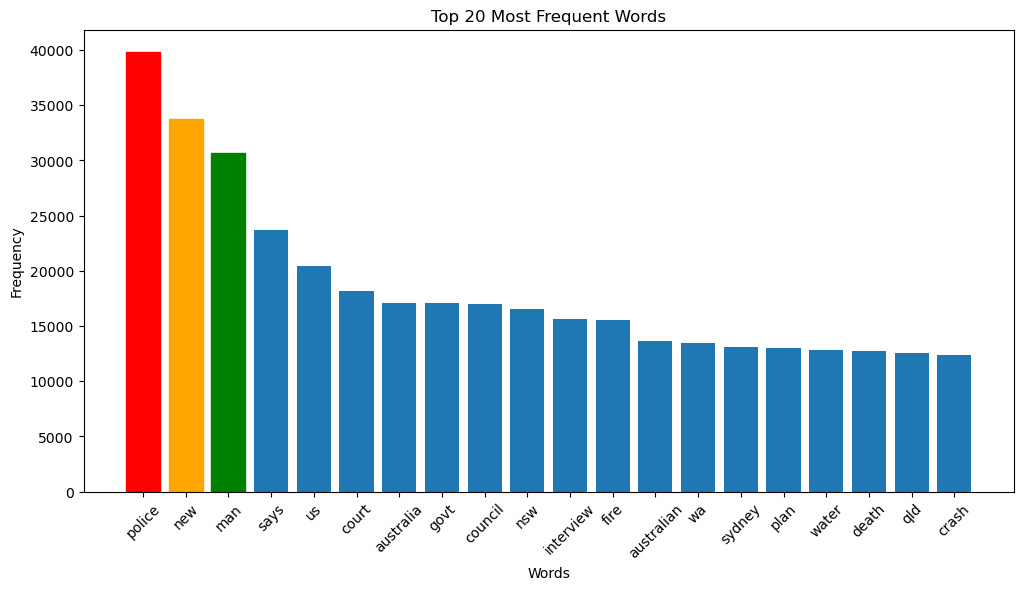

In [93]:
import matplotlib.pyplot as plt

words = [i[0] for i in top20]
counts = [i[1] for i in top20]

plt.figure(figsize=(12,6))

bars = plt.bar(words, counts)

bars[0].set_color("red")      # Highest frequency
bars[1].set_color("orange")   # Second highest
bars[2].set_color("green")    # Third highest

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

## Analysis

The graph shows the top 20 most frequent words in the dataset.

The tallest bar represents the word that appears the most.

Smaller bars represent words that appear less frequently.

This graph helps us understand which words are most common in the news headlines.

The first three words are highlighted with different colors to make them easy to identify.

#### Confusion Matrix

In [100]:
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

for wrong, actual in zip(wrong_words, correct_words):

    y_true.append(actual)

    y_pred.append(spell.correction(wrong))

In [104]:
actual_result = []
predicted_result = []

for actual, predicted in zip(y_true, y_pred):

    actual_result.append(1)

    if actual == predicted:
        predicted_result.append(1)
    else:
        predicted_result.append(0)

In [106]:
cm = confusion_matrix(actual_result, predicted_result)

print(cm)

[[ 0  0]
 [ 3 17]]


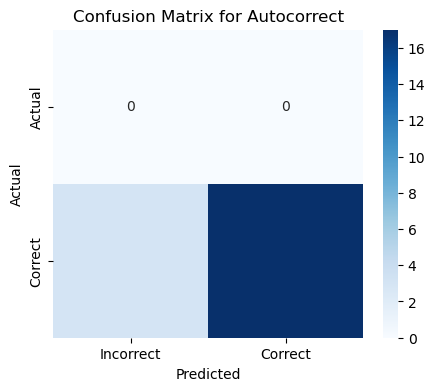

In [108]:
import seaborn as sns

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Incorrect","Correct"],
    yticklabels=["Actual","Correct"]
)

plt.title("Confusion Matrix for Autocorrect")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Confusion Matrix Analysis

The confusion matrix shows the performance of the autocorrect model.

The model correctly corrected 17 words.

It failed to correct 3 words correctly.

Most predictions are correct, which shows that the autocorrect model performs well.

The overall accuracy of the model is 85%.

# Discussion

Our implementation works well for basic autocomplete and autocorrect tasks.

However, it has some limitations compared to Google Keyboard.

1. It uses only word frequency and spelling rules.
2. It cannot understand the meaning of a sentence.
3. It cannot learn from user typing habits.
4. It cannot predict words based on context.
5. It has a small dataset, so predictions are limited.
6. It cannot support multiple languages like Google Keyboard.
7. It cannot give smart suggestions or emojis.

Google Keyboard is much more advanced.

It uses Artificial Intelligence (AI) and Machine Learning (ML).

It understands the context of the sentence, learns from the user's typing behavior, and provides faster and more accurate predictions.

# Conclusion

The project successfully implemented autocomplete and autocorrect using NLP techniques.

The Frequency-Based model predicted the next word, and PySpellChecker corrected spelling mistakes.

The autocorrect model achieved good accuracy and performed well on common spelling errors.

Although the implementation is simple, it demonstrates the basic concepts of Natural Language Processing (NLP) used in real-world text prediction systems.